In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack
import fitsio
# from astropy.io import fits

from matplotlib.ticker import FormatStrFormatter
sys.path.append(os.path.expanduser('~/git/desi-lrg-selection'))
import plotting_scripts as lrg_plot
import importlib
importlib.reload(lrg_plot)

<module 'plotting_scripts' from '/global/homes/r/rongpu/git/desi-lrg-selection/plotting_scripts.py'>

In [2]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
cat = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/spectro/sv1/testdenali_alltiles_Allzinfo_LRG_pz_added.fits'))
print(len(cat))
print(len(np.unique(cat['TARGETID'])))

52268
52023


In [4]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    cat['gmag'] = 22.5 - 2.5*np.log10(cat['FLUX_G']) - 3.214 * cat['EBV']
    cat['rmag'] = 22.5 - 2.5*np.log10(cat['FLUX_R']) - 2.165 * cat['EBV']
    cat['zmag'] = 22.5 - 2.5*np.log10(cat['FLUX_Z']) - 1.211 * cat['EBV']
    cat['w1mag'] = 22.5 - 2.5*np.log10(cat['FLUX_W1']) - 0.184 * cat['EBV']
    cat['w2mag'] = 22.5 - 2.5*np.log10(cat['FLUX_W2']) - 0.113 * cat['EBV']
    cat['rfibermag'] = 22.5 - 2.5*np.log10(cat['FIBERFLUX_R']) - 2.165 * cat['EBV']
    cat['zfibermag'] = 22.5 - 2.5*np.log10(cat['FIBERFLUX_Z']) - 1.211 * cat['EBV']

In [5]:
# Remove FIBERSTATUS!=0 fibers
mask = cat['FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove "no data" fibers
mask = cat['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Require a minimum depth for the deep coadd
min_depth = 2000.
mask = cat['EFFTIME_DARK']>min_depth
print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
cat = cat[mask]

print(len(cat))

FIBERSTATUS 43371 8897 0.17021887196755184
No data 43368 3 6.917064397869545e-05
Min depth 36843 6525 0.8495434421693414
36843


In [6]:
mask_quality0 = cat['ZWARN']==0
mask_quality0 &= cat['DELTACHI2']>15
mask_quality0 &= cat['Z']<1.4
print(np.sum(~mask_quality0)/len(mask_quality0))

# Custom DELTACHI2 vs z cut
d = (10**(3 - 3.5*cat['Z']))
mask_remove = (d>30) & (cat['DELTACHI2']<30)
mask_remove |= (d<30) & (cat['DELTACHI2']<d)
mask_remove |= (cat['DELTACHI2']<10)
mask_quality = cat['ZWARN']==0
mask_quality &= cat['Z']<1.4
mask_quality &= (~mask_remove)
print(np.sum(~mask_quality)/len(mask_quality))

cat = cat[mask_quality]
print(len(cat))

0.025893656868333198
0.024943679939201477
35924


In [7]:
# WISE and MEDIUM masks
maskbits = [8, 9, 11]
mask_clean = np.ones(len(cat), dtype=bool)
for bit in maskbits:
    mask_clean &= (cat['MASKBITS'] & 2**bit)==0
print('MASKBITS', np.sum(mask_clean), np.sum(~mask_clean), np.sum(mask_clean)/len(mask_clean))
cat = cat[mask_clean]

MASKBITS 33210 2714 0.92445162008685


In [8]:
mask_zfib = cat['zfibermag']<21.8
print(np.sum(mask_zfib)/len(mask))

# Select LRG_SV_IR
sv_ir = cat['SV1_DESI_TARGET'] & 2**6 > 0
print(np.sum(sv_ir)/len(sv_ir))

mask = mask_zfib & sv_ir
print(np.sum(mask))
cat = cat[mask]

# Remove QSO targets
mask_qso = cat['SV1_DESI_TARGET'] & 2**2 > 0
print(np.sum(mask_qso)/len(cat))

cat = cat[~mask_qso]
print(len(cat))

0.6223021582733813
0.8660945498343873
22849
0.043765591491969014
21849


10217 11632


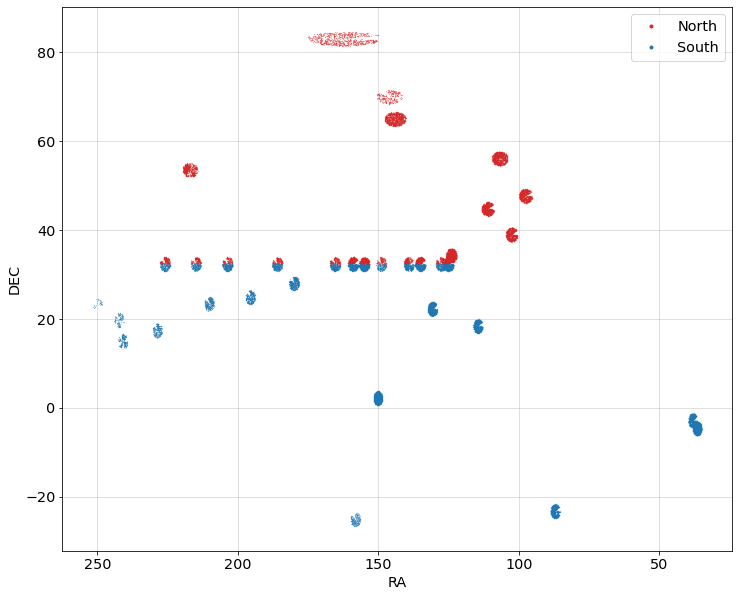

In [9]:
mask_north = cat['PHOTSYS']=='N'
mask_south = cat['PHOTSYS']=='S'
print(np.sum(mask_north), np.sum(mask_south))

plt.figure(figsize=(12, 10))
plt.plot(cat['TARGET_RA'][mask_north], cat['TARGET_DEC'][mask_north], 'C3.', ms=.3, label='North')
plt.plot(cat['TARGET_RA'][mask_south], cat['TARGET_DEC'][mask_south], 'C0.', ms=.3, label='South')
plt.xlabel('RA')
plt.ylabel('DEC')
plt.legend(loc='upper right', markerscale=20)
plt.grid(alpha=0.5)
plt.gca().invert_xaxis()
plt.show()

In [12]:
# numbers from another notebook
area_south = 8.213816897925716
area_north = 7.076690685846721
area = area_south + area_north
print(area_south)
print(area_north)
print(area)

8.213816897925716
7.076690685846721
15.290507583772436


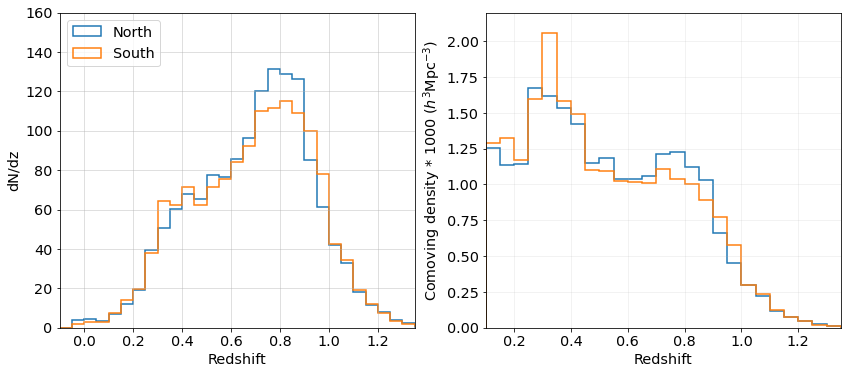

In [15]:
bins = np.arange(-0.1, 1.45, 0.05)
bin_centers = (bins[1:]+bins[:-1])/2

fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))
axes[0].hist(cat['Z'][mask_north], weights=np.ones(int(np.sum(mask_north)))/area_north,
             bins=bins, lw=1.5, histtype='step', label='North', color='C0')
axes[0].hist(cat['Z'][mask_south], weights=np.ones(int(np.sum(mask_south)))/area_south,
             bins=bins, lw=1.5, histtype='step', label='South', color='C1')
# axes[0].hist(bin_centers, counts_final/area, yerr=frac_err*counts_final/area, fmt='o', ms=5, color='C0', capsize=3, capthick=1, label='New Baseline')
axes[0].legend(loc='upper left')
axes[0].set_xlabel('Redshift')
axes[0].set_ylabel('dN/dz')
axes[0].set_xlim(-0.1, 1.35)
axes[0].set_ylim(0, 160)
axes[0].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
axes[0].grid(alpha=0.5)
# axes[0].set_ylim(top=30)
axes[1] = lrg_plot.plot_comoving_density(cat['Z'][mask_north], area=area_north, zmin=0.1, zmax=bins.max(), dz=0.05, axis=[0.1, 1.35, 0, 2.2], xlabel='Redshift', show=False, lw=1.5, color='C0', errorbar=False)
axes[1] = lrg_plot.plot_comoving_density(cat['Z'][mask_south], area=area_south, zmin=0.1, zmax=bins.max(), dz=0.05, axis=[0.1, 1.35, 0, 2.2], xlabel='Redshift', show=False, lw=1.5, color='C1', errorbar=False)
# plt.legend(loc='lower left')
plt.show()

---------
# Photo-z bins

In [40]:
pz_absolute_min = 0.25
pz_cuts_south = [0.468, 0.655, 0.792, 0.886]
pz_cuts_north = [0.468, 0.655, 0.792, 0.886]  # Not the actual cuts for north

print('South:')
for index in range(-1, len(pz_cuts_south)):
    if index==-1:
        pz_min, pz_max = -np.inf, pz_cuts_south[0]
    elif index==len(pz_cuts_south)-1:
        pz_min, pz_max = pz_cuts_south[index], np.inf
    else:
        pz_min, pz_max = pz_cuts_south[index], pz_cuts_south[index+1]
    mask = mask_south & (cat['Z_PHOT_MEDIAN']>pz_min) & (cat['Z_PHOT_MEDIAN']<pz_max)
    mask &= cat['Z_PHOT_MEDIAN']>pz_absolute_min
    print('bin {} fraction: {:.4f}'.format(index+2, np.sum(mask)/np.sum(mask_south)))

South:
bin 1 fraction: 0.1825
bin 2 fraction: 0.1932
bin 3 fraction: 0.1927
bin 4 fraction: 0.1908
bin 5 fraction: 0.2135


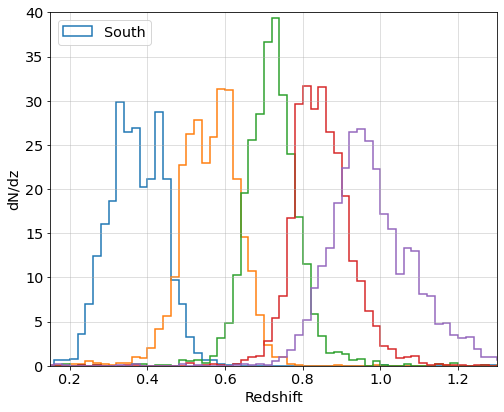

In [64]:
bins = np.arange(-0.1, 1.45, 0.02)
bin_centers = (bins[1:]+bins[:-1])/2

fig, ax = plt.subplots(figsize=(8, 6.5))

for index in range(-1, len(pz_cuts_south)):
    if index==-1:
        pz_min, pz_max = -np.inf, pz_cuts_south[0]
    elif index==len(pz_cuts_south)-1:
        pz_min, pz_max = pz_cuts_south[index], np.inf
    else:
        pz_min, pz_max = pz_cuts_south[index], pz_cuts_south[index+1]
    if index==-1:
        label = 'South'
    else:
        label = None
    mask = mask_south & (cat['Z_PHOT_MEDIAN']>pz_min) & (cat['Z_PHOT_MEDIAN']<pz_max)
    mask &= cat['Z_PHOT_MEDIAN']>pz_absolute_min
    ax.hist(cat['Z'][mask], weights=np.ones(int(np.sum(mask)))/area_south,
                 bins=bins, lw=1.5, histtype='step', label=label, color='C'+str(index+1))
ax.legend(loc='upper left')
ax.set_xlabel('Redshift')
ax.set_ylabel('dN/dz')
ax.set_xlim(0.15, 1.3)
ax.set_ylim(0, 40)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
ax.grid(alpha=0.5)
# ax.set_ylim(top=30)
# plt.legend(loc='lower left')
plt.show()

__Compare with main LRGs__

In [65]:
main_dndz = Table.read('data/main_lrg_pz_dndz.txt', format='ascii.commented_header')

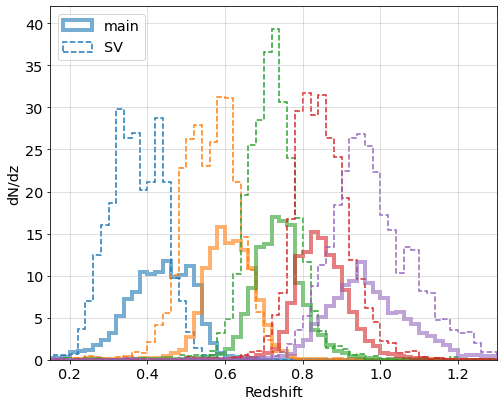

In [69]:
bins = np.arange(0, 1.48, 0.02)
bin_centers = (bins[1:]+bins[:-1])/2

fig, ax = plt.subplots(figsize=(8, 6.5))

for index in range(-1, len(pz_cuts_south)):
    if index==-1:
        pz_min, pz_max = -np.inf, pz_cuts_south[0]
    elif index==len(pz_cuts_south)-1:
        pz_min, pz_max = pz_cuts_south[index], np.inf
    else:
        pz_min, pz_max = pz_cuts_south[index], pz_cuts_south[index+1]
    if index==-1:
        label_main = 'main'
        label_sv = 'SV'
    else:
        label_main = None
        label_sv = None
    mask = mask_south & (cat['Z_PHOT_MEDIAN']>pz_min) & (cat['Z_PHOT_MEDIAN']<pz_max)
    mask &= cat['Z_PHOT_MEDIAN']>pz_absolute_min
    ax.hist(bins, weights=main_dndz['bin_{}_south'.format(index+2)], label=label_main,
                 bins=bins, lw=4, histtype='step', color='C'+str(index+1), alpha=0.6)
    ax.hist(cat['Z'][mask], weights=np.ones(int(np.sum(mask)))/area_south, label=label_sv,
                 bins=bins, lw=1.5, histtype='step', ls='--', color='C'+str(index+1))
ax.legend(loc='upper left')
ax.set_xlabel('Redshift')
ax.set_ylabel('dN/dz')
ax.set_xlim(0.15, 1.3)
ax.set_ylim(0, 42)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
ax.grid(alpha=0.5)
# ax.set_ylim(top=30)
# plt.legend(loc='lower left')
plt.show()